In [1]:
import json
import os
from pathlib import Path

# データファイルのパス
repo_path = Path("/workspace/k8s-repo/website")
translation_status_path = Path("/workspace/data/output/translation_status.json")

# 翻訳状況データを読み込み
with open(translation_status_path, 'r', encoding='utf-8') as f:
    translation_data = json.load(f)

print(f"読み込んだファイル数: {len(translation_data)}")
print(f"最初の5件のキー: {list(translation_data.keys())[:5]}")

読み込んだファイル数: 36752
最初の5件のキー: ['content/bn/_common-resources/index.md', 'content/bn/_index.html', 'content/bn/blog/_index.md', 'content/bn/blog/_posts/2015-03-00-Kubernetes-Gathering-Videos.md', 'content/bn/blog/_posts/2015-03-00-Participate-In-Kubernetes-User.md']


In [2]:
# Function to get effective line count (excluding comments, empty lines, and front matter)
def get_file_line_count(file_path):
    """Returns the effective line count, excluding HTML comments, empty lines, and YAML front matter"""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        effective_lines = 0
        in_comment = False
        in_front_matter = False
        front_matter_count = 0
        
        for line in lines:
            stripped = line.strip()
            
            # Handle YAML front matter (--- ... ---)
            if stripped == '---':
                front_matter_count += 1
                if front_matter_count == 1:
                    in_front_matter = True
                    continue
                elif front_matter_count == 2:
                    in_front_matter = False
                    continue
            
            # Skip lines inside front matter
            if in_front_matter:
                continue
            
            # Skip empty lines
            if not stripped:
                continue
            
            # Handle HTML comments (<!-- -->)
            if '<!--' in stripped:
                in_comment = True
                # Check if comment ends on same line
                if '-->' in stripped:
                    in_comment = False
                continue
            
            # Skip lines inside comment
            if in_comment:
                if '-->' in stripped:
                    in_comment = False
                continue
            
            # Count this line as effective
            effective_lines += 1
        
        return effective_lines
    except Exception as e:
        return None

# Sample: Compare line counts for Japanese translations
samples = []
for path, data in list(translation_data.items())[:20]:
    if data.get('language') != 'ja':
        continue
    
    en_path = repo_path / data.get('english_path', '')
    ja_path = repo_path / path
    
    if en_path.exists() and ja_path.exists():
        en_lines = get_file_line_count(en_path)
        ja_lines = get_file_line_count(ja_path)
        
        if en_lines and ja_lines:
            diff_percent = ((en_lines - ja_lines) / en_lines * 100) if en_lines > 0 else 0
            samples.append({
                'path': path,
                'status': data['history']['status'],
                'en_lines': en_lines,
                'ja_lines': ja_lines,
                'diff_percent': diff_percent
            })

# Display results
print("Effective line count (excluding front matter, comments, and empty lines):\n")
for s in samples[:10]:
    print(f"{s['status']:20} | EN: {s['en_lines']:4} | JA: {s['ja_lines']:4} | Diff: {s['diff_percent']:+6.1f}% | {s['path']}")

Effective line count (excluding front matter, comments, and empty lines):



## Data Visualization Preparation

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 全ファイルの行数を収集
all_data = []
for path, data in translation_data.items():
    lang = data.get('language')
    if lang == 'en':  # 英語版はスキップ
        continue
    
    en_path = repo_path / data.get('english_path', '')
    trans_path = repo_path / path
    
    if en_path.exists() and trans_path.exists():
        en_lines = get_file_line_count(en_path)
        trans_lines = get_file_line_count(trans_path)
        
        if en_lines and trans_lines:
            diff_percent = ((en_lines - trans_lines) / en_lines * 100) if en_lines > 0 else 0
            all_data.append({
                'language': lang,
                'path': path,
                'status': data['history']['status'],
                'en_lines': en_lines,
                'trans_lines': trans_lines,
                'diff_percent': diff_percent
            })

print(f"分析対象: {len(all_data)} ファイル")

分析対象: 4357 ファイル


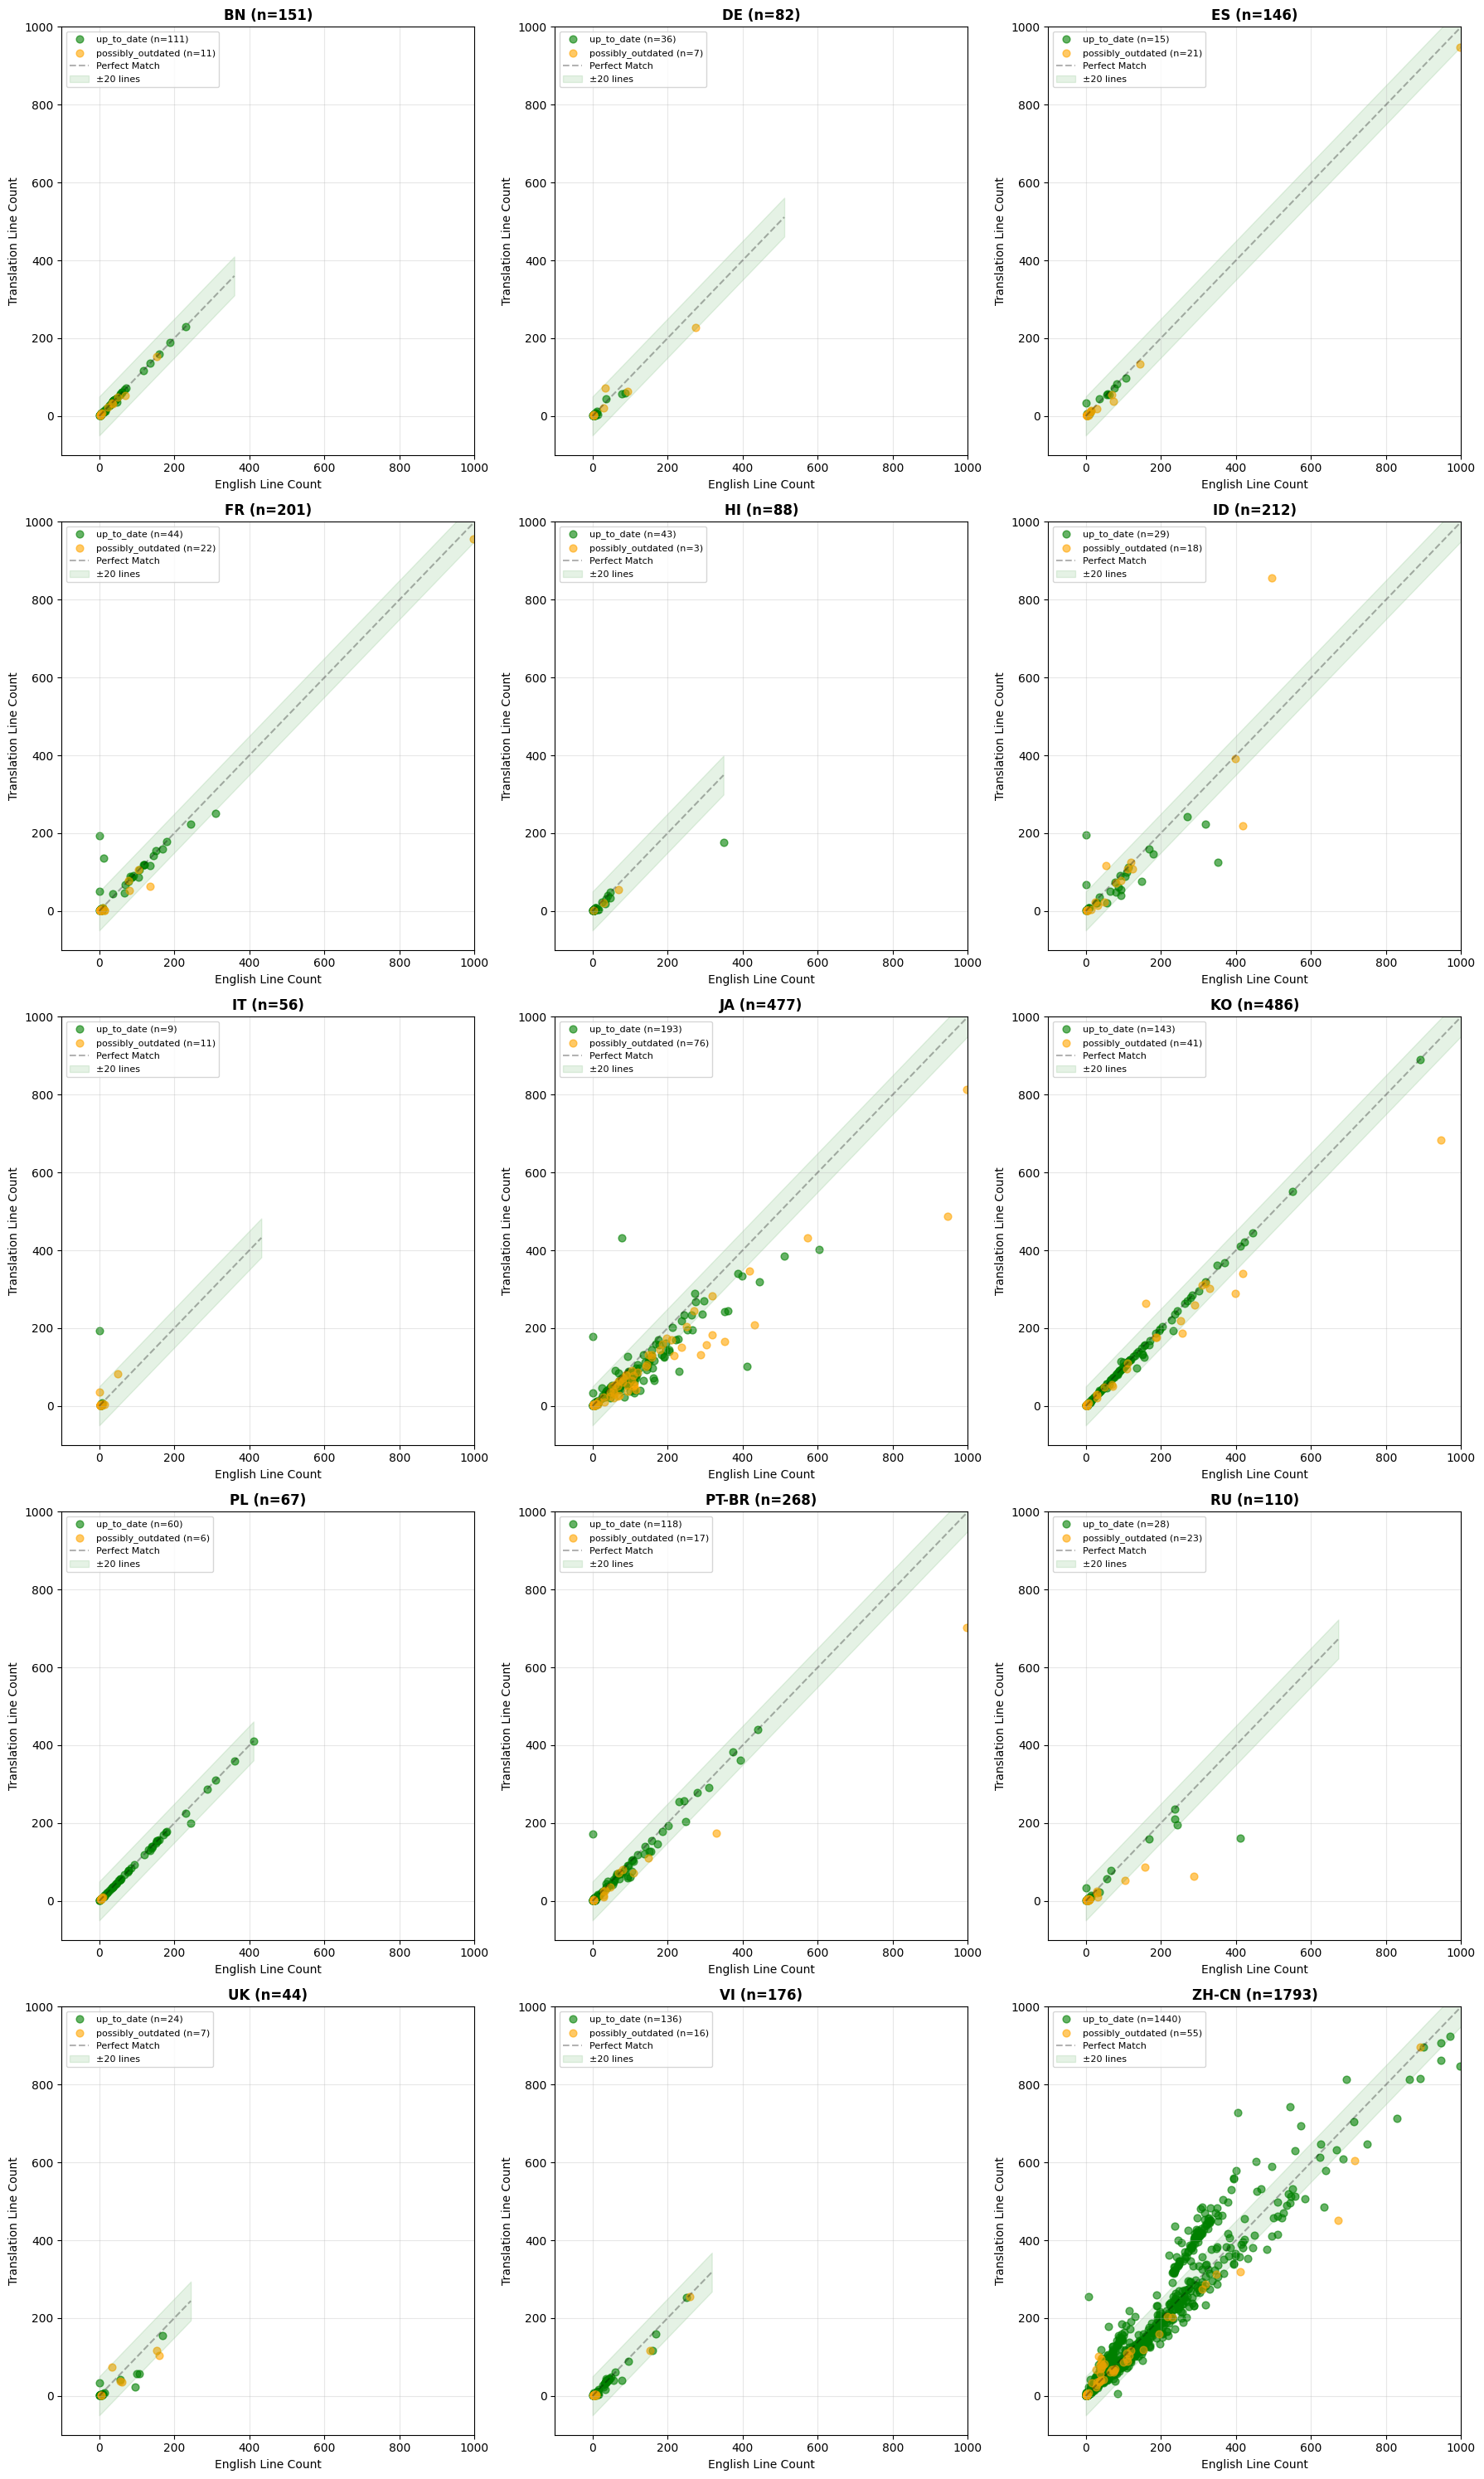

In [5]:
# Scatter plots: English vs Translation line count (by language)
# Get languages with sufficient data
lang_counts = {}
for item in all_data:
    lang = item['language']
    lang_counts[lang] = lang_counts.get(lang, 0) + 1

# Filter languages with at least 20 files
major_langs = sorted([lang for lang, count in lang_counts.items() if count >= 20])

# Calculate grid size
n_langs = len(major_langs)
n_cols = 3
n_rows = (n_langs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten() if n_langs > 1 else [axes]

# Color by status
status_colors = {
    'up_to_date': 'green',
    'outdated': 'red',
    'possibly_outdated': 'orange',
    'not_translated': 'gray'
}

for idx, lang in enumerate(major_langs):
    ax = axes[idx]
    lang_data = [item for item in all_data if item['language'] == lang]
    
    # Plot by status
    # for status in ['up_to_date', 'possibly_outdated', 'outdated']:
    for status in ['up_to_date', 'possibly_outdated']:
        status_lang_data = [item for item in lang_data if item['status'] == status]
        if status_lang_data:
            en_lines = [item['en_lines'] for item in status_lang_data]
            trans_lines = [item['trans_lines'] for item in status_lang_data]
            
            ax.scatter(en_lines, trans_lines, 
                       alpha=0.6, 
                       s=40,
                       c=status_colors.get(status, 'blue'),
                       label=f'{status} (n={len(status_lang_data)})')
    
    # Add diagonal line (perfect match)
    max_lines = max(max([item['en_lines'] for item in lang_data]), 
                    max([item['trans_lines'] for item in lang_data]))
    ax.plot([0, max_lines], [0, max_lines], 'k--', alpha=0.3, linewidth=1.5, label='Perfect Match')
    
    # Add ±10% band
    # x_range = np.linspace(0, max_lines, 100)
    # ax.fill_between(x_range, 
    #                 x_range * 0.9, 
    #                 x_range * 1.1, 
    #                 alpha=0.1, color='green')
    x_range = np.linspace(0, max_lines, 100)
    ax.fill_between(x_range, x_range - 50, x_range + 50, alpha=0.1, color='green', label='±20 lines')

    ax.set_xlabel('English Line Count', fontsize=10)
    ax.set_ylabel('Translation Line Count', fontsize=10)
    ax.set_title(f'{lang.upper()} (n={len(lang_data)})', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-100, 1000)
    ax.set_ylim(-100, 1000)

# Hide unused subplots
for idx in range(n_langs, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Detailed Analysis: Japanese (JA) Translation

Let's examine Japanese translation patterns in more detail.

In [6]:
# Detailed Japanese translation scatter plots
ja_data = [item for item in all_data if item['language'] == 'ja']

# Calculate ratio for each file
for item in ja_data:
    item['ratio'] = item['trans_lines'] / item['en_lines'] if item['en_lines'] > 0 else 0

# Separate by status
ja_up_to_date = [item for item in ja_data if item['status'] == 'up_to_date']
ja_possibly_outdated = [item for item in ja_data if item['status'] == 'possibly_outdated']
ja_outdated = [item for item in ja_data if item['status'] == 'outdated']

print(f"Total Japanese files: {len(ja_data)}")
print(f"  up_to_date: {len(ja_up_to_date)}")
print(f"  possibly_outdated: {len(ja_possibly_outdated)}")
print(f"  outdated: {len(ja_outdated)}")
print()

# Statistics
ratios = [item['ratio'] for item in ja_data]
print(f"Ratio statistics (JA lines / EN lines):")
print(f"  Mean: {np.mean(ratios):.3f}")
print(f"  Median: {np.median(ratios):.3f}")
print(f"  Std Dev: {np.std(ratios):.3f}")
print(f"  Min: {min(ratios):.3f}")
print(f"  Max: {max(ratios):.3f}")

Total Japanese files: 477
  up_to_date: 193
  possibly_outdated: 76
  outdated: 208

Ratio statistics (JA lines / EN lines):
  Mean: 1.197
  Median: 0.747
  Std Dev: 8.290
  Min: 0.007
  Max: 179.000


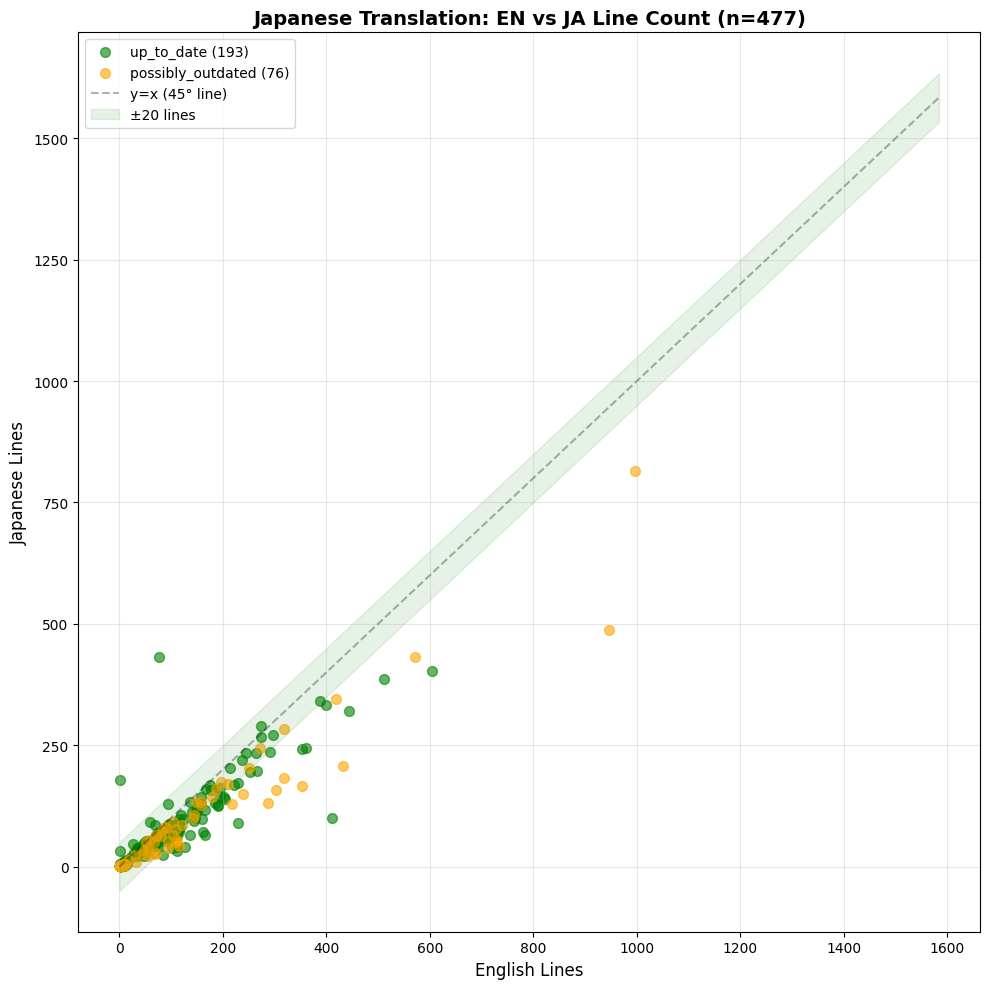

In [7]:
# Create detailed scatter plot for Japanese
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot by status with different colors
if ja_up_to_date:
    ax.scatter(
        [item['en_lines'] for item in ja_up_to_date],
        [item['trans_lines'] for item in ja_up_to_date],
        c='green', alpha=0.6, s=50, label=f'up_to_date ({len(ja_up_to_date)})'
    )

if ja_possibly_outdated:
    ax.scatter(
        [item['en_lines'] for item in ja_possibly_outdated],
        [item['trans_lines'] for item in ja_possibly_outdated],
        c='orange', alpha=0.6, s=50, label=f'possibly_outdated ({len(ja_possibly_outdated)})'
    )

# if ja_outdated:
#     ax.scatter(
#         [item['en_lines'] for item in ja_outdated],
#         [item['trans_lines'] for item in ja_outdated],
#         c='red', alpha=0.6, s=50, label=f'outdated ({len(ja_outdated)})'
#     )

# Add reference lines
max_val = max([item['en_lines'] for item in ja_data] + [item['trans_lines'] for item in ja_data])
x_ref = np.linspace(0, max_val, 100)
ax.plot(x_ref, x_ref, 'k--', alpha=0.3, label='y=x (45° line)')

# ±20 lines band
ax.fill_between(x_ref, x_ref - 50, x_ref + 50, alpha=0.1, color='green', label='±20 lines')

ax.set_xlabel('English Lines', fontsize=12)
ax.set_ylabel('Japanese Lines', fontsize=12)
ax.set_title(f'Japanese Translation: EN vs JA Line Count (n={len(ja_data)})', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Chinese Translation: Files with Large Discrepancies

Let's identify Chinese translation files with the largest line count differences.

In [11]:
# Filter Chinese translation data
zh_data = [item for item in all_data if item['language'] == 'ja']

# Calculate absolute difference and ratio for each file
for item in zh_data:
    item['abs_diff'] = abs(item['trans_lines'] - item['en_lines'])
    item['ratio'] = item['trans_lines'] / item['en_lines'] if item['en_lines'] > 0 else 0

# Sort by absolute difference (descending)
zh_sorted = sorted(zh_data, key=lambda x: x['abs_diff'], reverse=True)

print(f"Top 10 Chinese translation files with largest line count discrepancies:\n")
print(f"{'Status':<20} | {'EN':<5} | {'ZH':<5} | {'Diff':<6} | {'Ratio':<5} | Path")
print("-" * 100)

for item in zh_sorted[:30]:
    status = item['status']
    en = item['en_lines']
    zh = item['trans_lines']
    diff = item['abs_diff']
    ratio = item['ratio']
    path = item['path']
    
    print(f"{status:<20} | {en:<5} | {zh:<5} | {diff:<6} | {ratio:<5.2f} | {path}")

Top 10 Chinese translation files with largest line count discrepancies:

Status               | EN    | ZH    | Diff   | Ratio | Path
----------------------------------------------------------------------------------------------------
outdated             | 1584  | 519   | 1065   | 0.33  | content/ja/docs/reference/access-authn-authz/authentication.md
outdated             | 685   | 173   | 512    | 0.25  | content/ja/docs/concepts/scheduling-eviction/dynamic-resource-allocation.md
outdated             | 717   | 209   | 508    | 0.29  | content/ja/docs/concepts/workloads/pods/pod-lifecycle.md
outdated             | 1028  | 550   | 478    | 0.54  | content/ja/docs/concepts/storage/persistent-volumes.md
possibly_outdated    | 947   | 487   | 460    | 0.51  | content/ja/docs/concepts/workloads/controllers/job.md
up_to_date           | 77    | 431   | 354    | 5.60  | content/ja/docs/reference/command-line-tools-reference/feature-gates/index.md
outdated             | 496   | 817   | 321    

## Ratio Distribution Analysis

Histogram of translation/English line count ratio for each language.

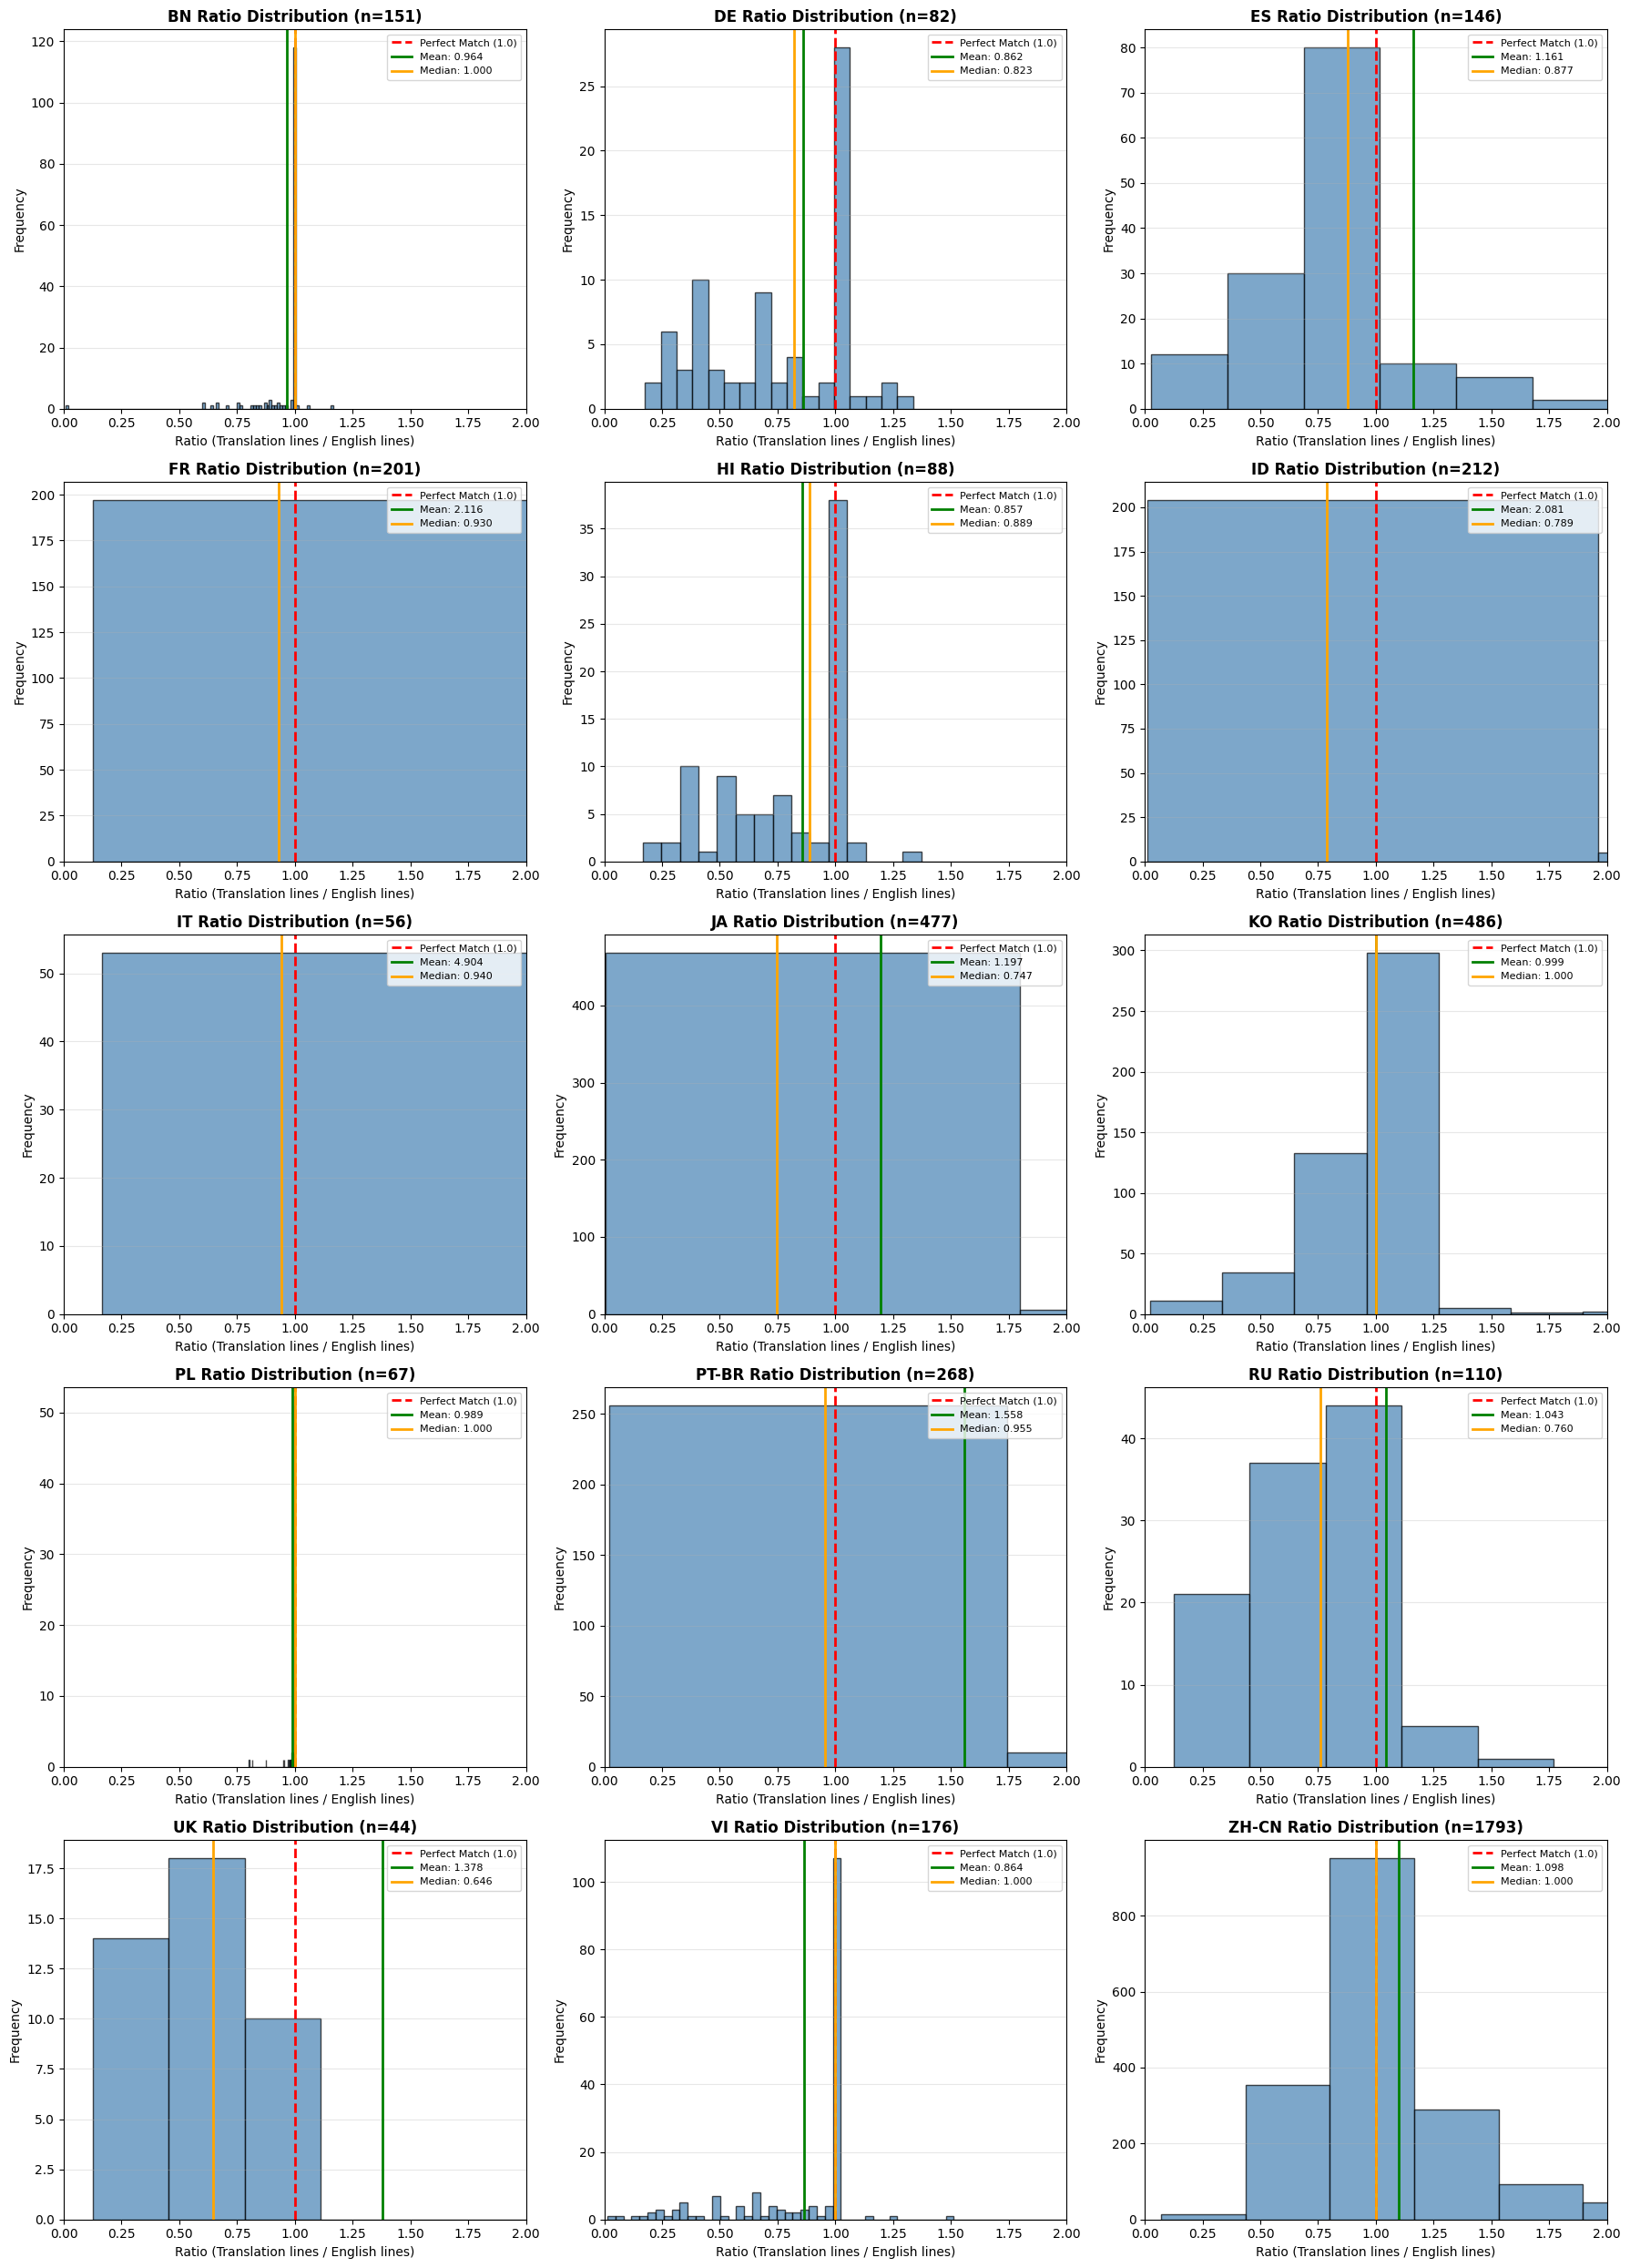

In [14]:
# Calculate ratio for all files
for item in all_data:
    item['ratio'] = item['trans_lines'] / item['en_lines'] if item['en_lines'] > 0 else 0

# Get major languages
lang_counts = {}
for item in all_data:
    lang = item['language']
    lang_counts[lang] = lang_counts.get(lang, 0) + 1

major_langs = sorted([lang for lang, count in lang_counts.items() if count >= 20])

# Create histograms
n_langs = len(major_langs)
n_cols = 3
n_rows = (n_langs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() if n_langs > 1 else [axes]

for idx, lang in enumerate(major_langs):
    ax = axes[idx]
    lang_data = [item for item in all_data if item['language'] == lang]
    ratios = [item['ratio'] for item in lang_data]
    
    # Create histogram
    ax.hist(ratios, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Add vertical line at ratio=1.0 (perfect match)
    ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Perfect Match (1.0)')
    
    # Statistics
    mean_ratio = np.mean(ratios)
    median_ratio = np.median(ratios)
    ax.axvline(x=mean_ratio, color='green', linestyle='-', linewidth=2, label=f'Mean: {mean_ratio:.3f}')
    ax.axvline(x=median_ratio, color='orange', linestyle='-', linewidth=2, label=f'Median: {median_ratio:.3f}')
    
    ax.set_xlabel('Ratio (Translation lines / English lines)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{lang.upper()} Ratio Distribution (n={len(lang_data)})', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlim(0, 2)

# Hide unused subplots
for idx in range(n_langs, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Print summary statistics for each language
print("Ratio Statistics by Language (Translation lines / English lines):\n")
print(f"{'Language':<10} | {'Count':<6} | {'Mean':<6} | {'Median':<6} | {'Std':<6} | {'Min':<6} | {'Max':<6}")
print("-" * 70)

for lang in major_langs:
    lang_data = [item for item in all_data if item['language'] == lang]
    ratios = [item['ratio'] for item in lang_data]
    
    print(f"{lang:<10} | {len(ratios):<6} | {np.mean(ratios):<6.3f} | {np.median(ratios):<6.3f} | {np.std(ratios):<6.3f} | {min(ratios):<6.3f} | {max(ratios):<6.3f}")